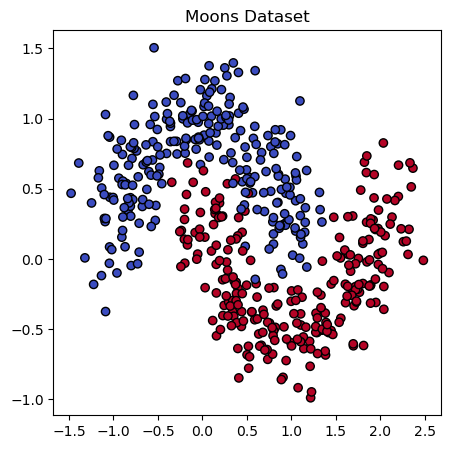

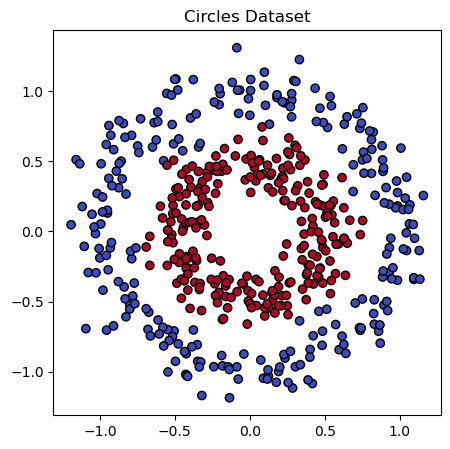

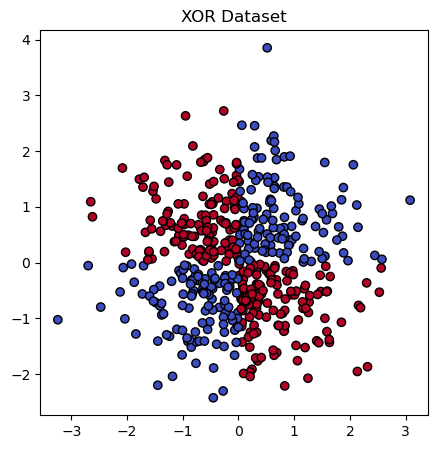


================ Multi-Class SVM ================

One-vs-One Accuracy: 1.0
One-vs-Rest Accuracy: 1.0

================ Experiment Completed ================



In [1]:
# ==========================================================
# EXPERIMENT 8
# SVM WITH NON-LINEAR KERNELS
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.datasets import make_moons, make_circles, make_blobs
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

# ==========================================================
# PART A — DATA GENERATION
# ==========================================================

# 1) Moons Dataset
X_moons, y_moons = make_moons(n_samples=500, noise=0.2, random_state=42)

# 2) Circles Dataset
X_circles, y_circles = make_circles(n_samples=500, noise=0.1, factor=0.5, random_state=42)

# 3) XOR Dataset
np.random.seed(42)
X_xor = np.random.randn(500, 2)
y_xor = np.logical_xor(X_xor[:, 0] > 0, X_xor[:, 1] > 0)
y_xor = np.where(y_xor, 1, 0)

# ==========================================================
# FUNCTION TO PLOT DATASET
# ==========================================================

def plot_dataset(X, y, title):
    plt.figure(figsize=(5,5))
    plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', edgecolors='k')
    plt.title(title)
    plt.show()

plot_dataset(X_moons, y_moons, "Moons Dataset")
plot_dataset(X_circles, y_circles, "Circles Dataset")
plot_dataset(X_xor, y_xor, "XOR Dataset")

# ==========================================================
# FUNCTION TO PLOT DECISION BOUNDARY
# ==========================================================

def plot_decision_boundary(model, X, y, title):

    plt.figure(figsize=(6,5))

    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, cmap='coolwarm', alpha=0.3)
    plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', edgecolors='k')

    # Highlight support vectors
    plt.scatter(
        model.support_vectors_[:,0],
        model.support_vectors_[:,1],
        s=120,
        facecolors='none',
        edgecolors='black',
        label='Support Vectors'
    ) 


    plt.title(title)
    plt.legend()
    plt.show()



# ==========================================================
# BONUS — MULTI-CLASS CLASSIFICATION
# ==========================================================

print("\n================ Multi-Class SVM ================\n")

X_multi, y_multi = make_blobs(n_samples=500, centers=3, random_state=42)

model_ovo = svm.SVC(kernel='rbf', decision_function_shape='ovo')
model_ovr = svm.SVC(kernel='rbf', decision_function_shape='ovr')

model_ovo.fit(X_multi, y_multi)
model_ovr.fit(X_multi, y_multi)

print("One-vs-One Accuracy:", model_ovo.score(X_multi, y_multi))
print("One-vs-Rest Accuracy:", model_ovr.score(X_multi, y_multi))

print("\n================ Experiment Completed ================\n")


================ Moons Dataset ================

Linear Accuracy: 0.867


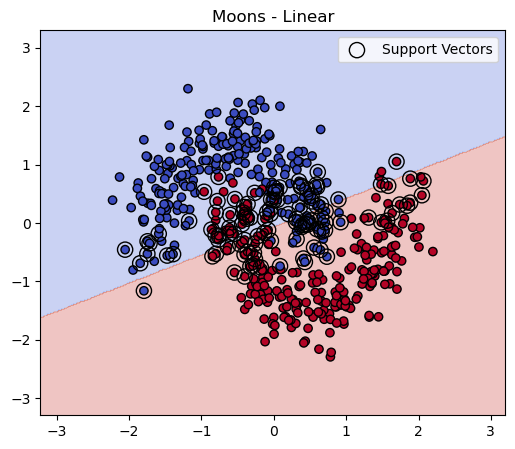

Polynomial_deg2 Accuracy: 0.493


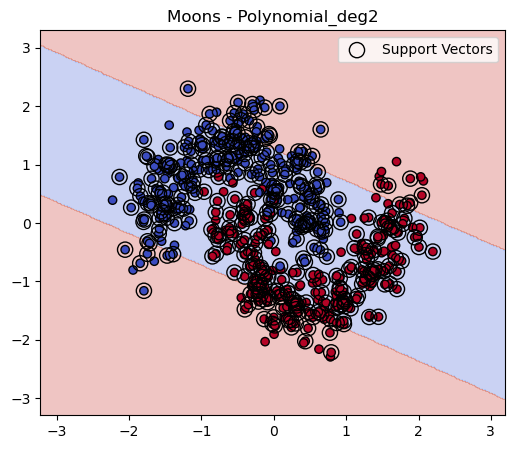

Polynomial_deg3 Accuracy: 0.887


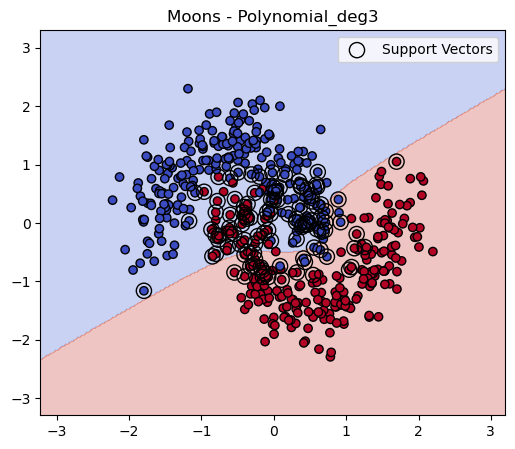

Polynomial_deg4 Accuracy: 0.493


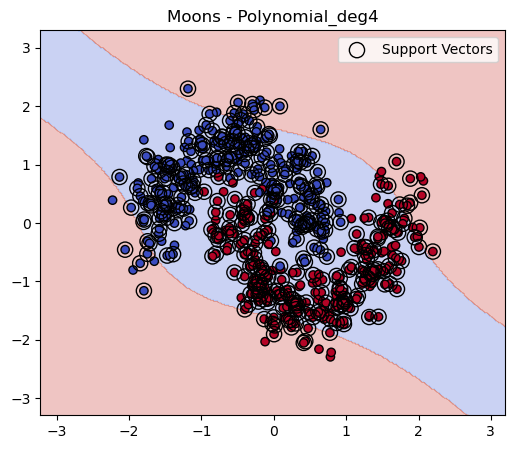

RBF_gamma_0.5 Accuracy: 0.973


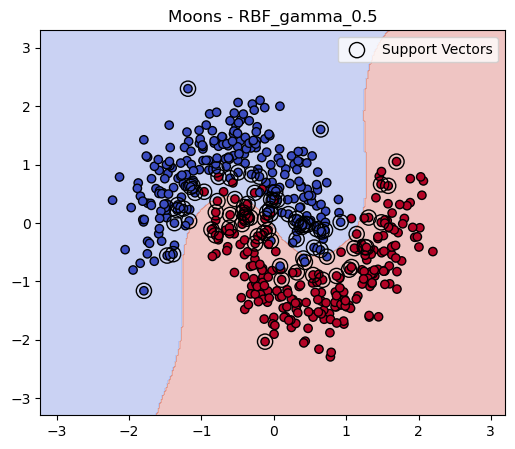

RBF_gamma_1 Accuracy: 0.980


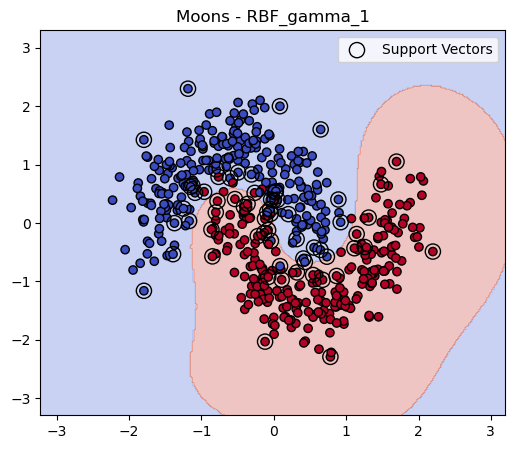

Sigmoid Accuracy: 0.733


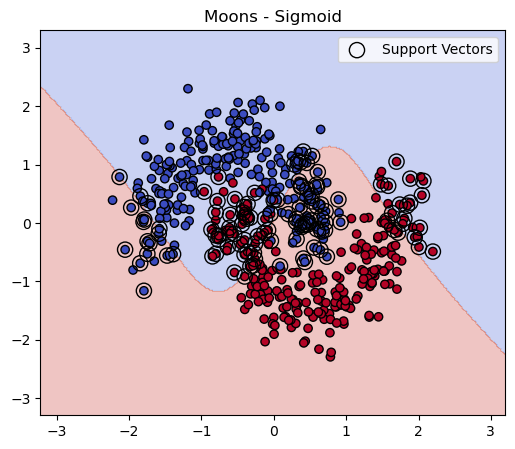


================ Circles Dataset ================

Linear Accuracy: 0.527


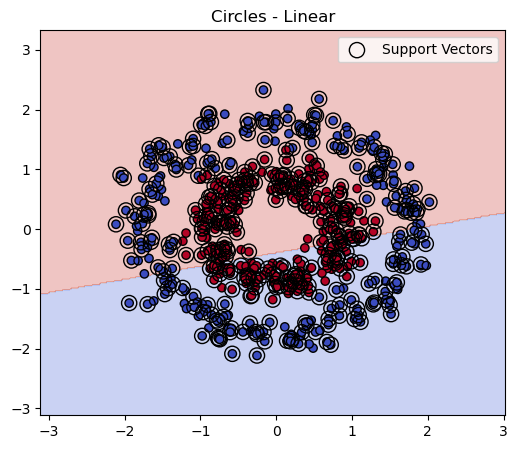

Polynomial_deg2 Accuracy: 0.993


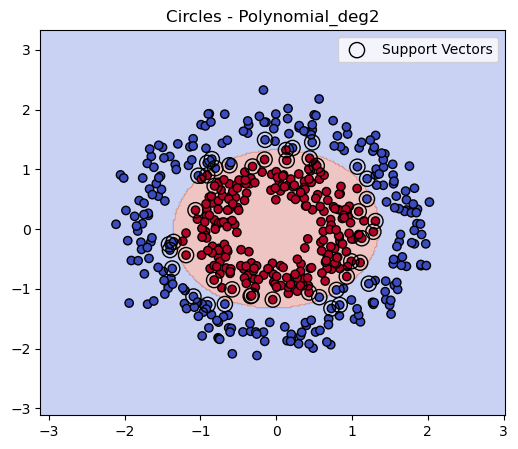

Polynomial_deg3 Accuracy: 0.653


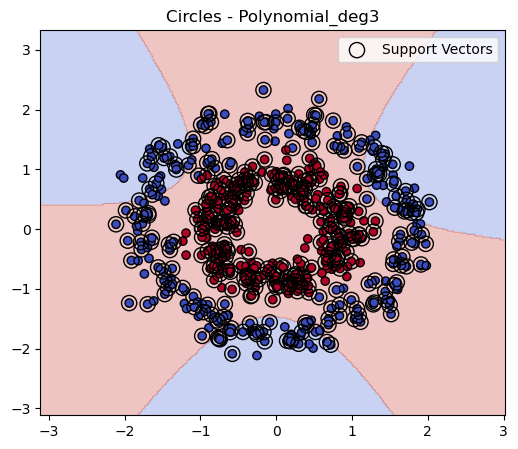

Polynomial_deg4 Accuracy: 0.993


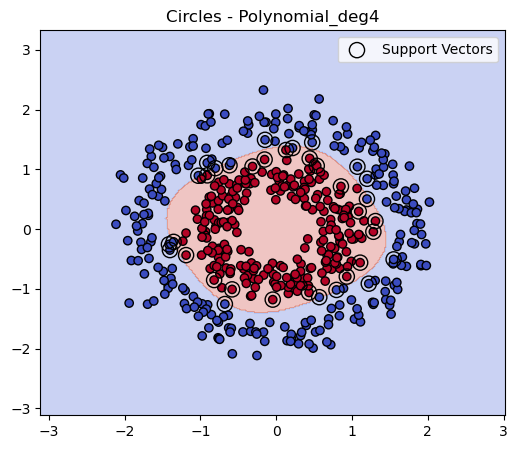

RBF_gamma_0.5 Accuracy: 0.987


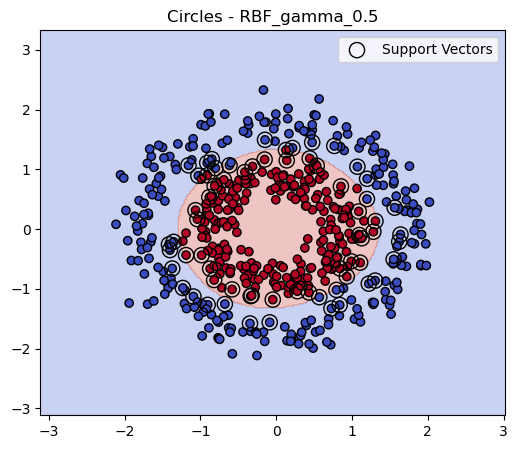

RBF_gamma_1 Accuracy: 0.987


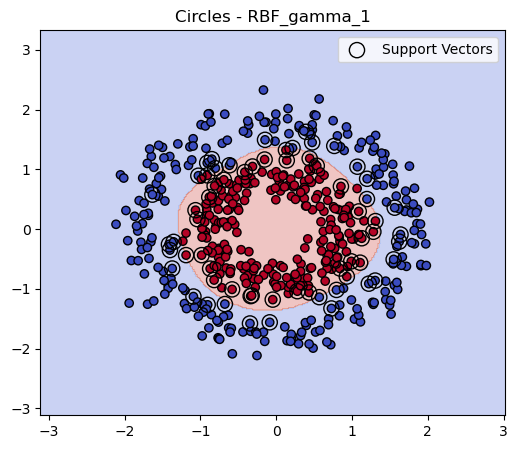

Sigmoid Accuracy: 0.493


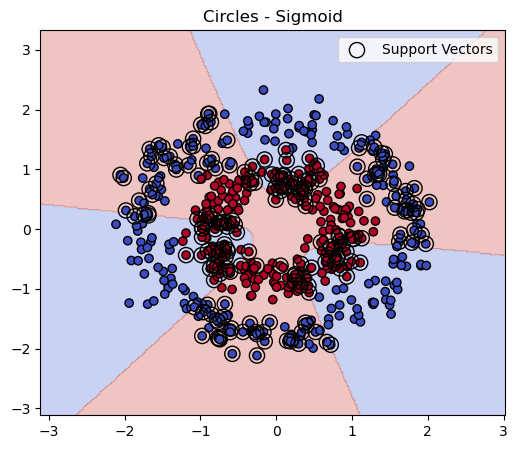


================ XOR Dataset ================

Linear Accuracy: 0.607


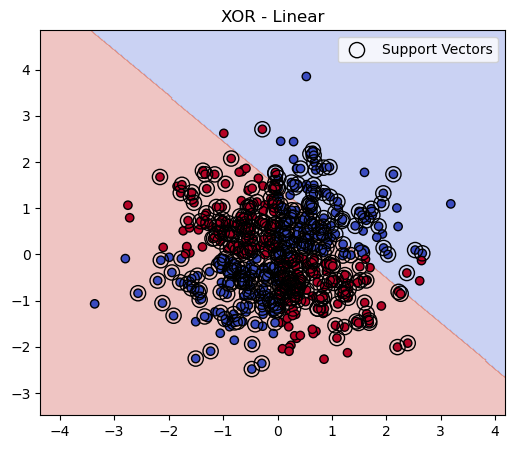

Polynomial_deg2 Accuracy: 0.980


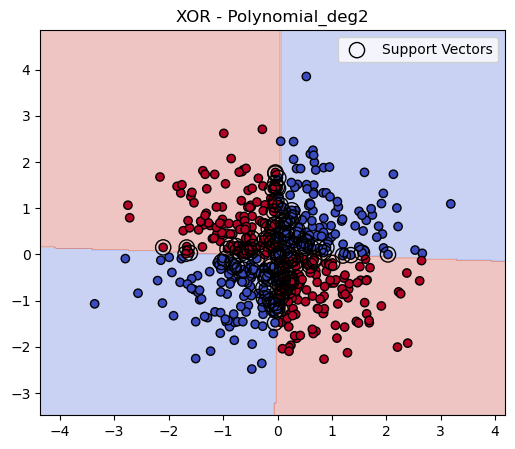

Polynomial_deg3 Accuracy: 0.533


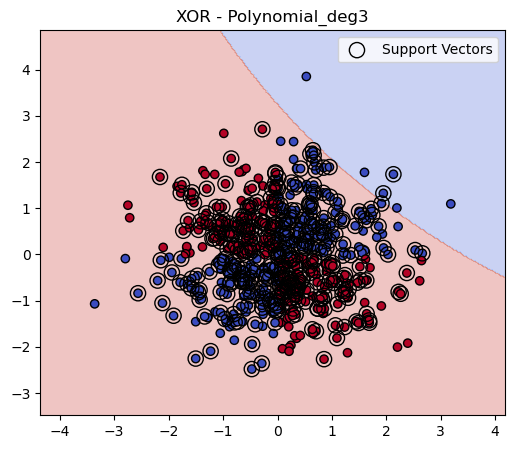

Polynomial_deg4 Accuracy: 0.900


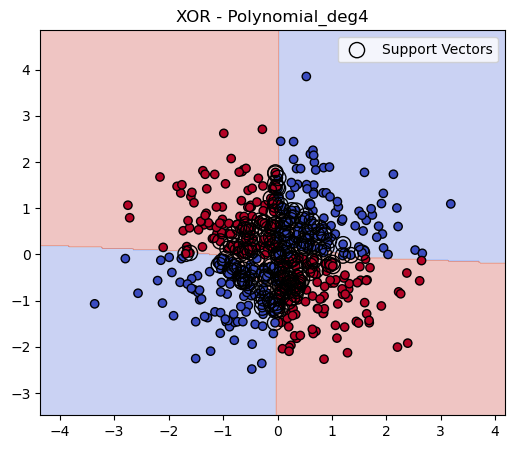

RBF_gamma_0.5 Accuracy: 0.933


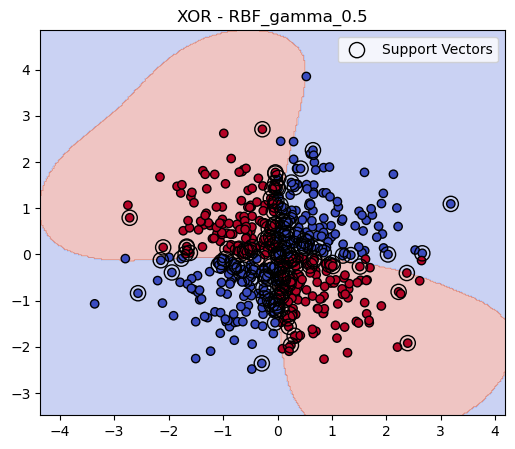

RBF_gamma_1 Accuracy: 0.947


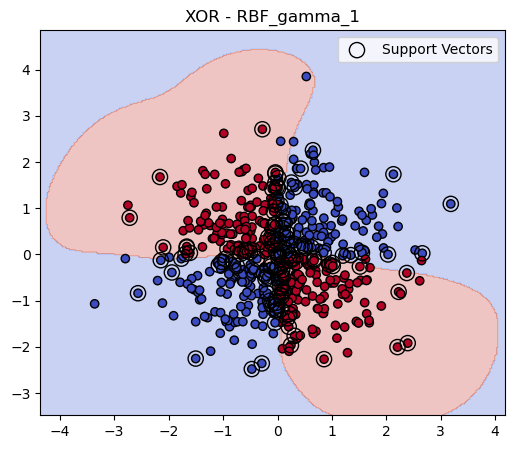

Sigmoid Accuracy: 0.507


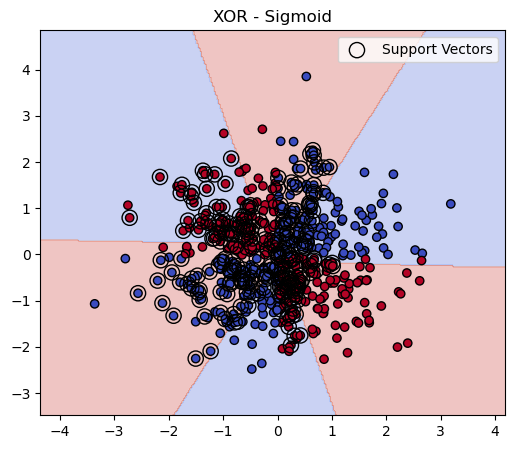

In [2]:
# ==========================================================
# PART B — SVM MODELS
# ==========================================================

models = {
    "Linear": svm.SVC(kernel='linear', C=1),
    "Polynomial_deg2": svm.SVC(kernel='poly', degree=2, C=1),
    "Polynomial_deg3": svm.SVC(kernel='poly', degree=3, C=1),
    "Polynomial_deg4": svm.SVC(kernel='poly', degree=4, C=1),
    "RBF_gamma_0.5": svm.SVC(kernel='rbf', gamma=0.5, C=1),
    "RBF_gamma_1": svm.SVC(kernel='rbf', gamma=1, C=1),
    "Sigmoid": svm.SVC(kernel='sigmoid', C=1)
}

datasets = {
    "Moons": (X_moons, y_moons),
    "Circles": (X_circles, y_circles),
    "XOR": (X_xor, y_xor)
}

# ==========================================================
# TRAIN AND EVALUATE
# ==========================================================

for dname, (X, y) in datasets.items():

    print(f"\n================ {dname} Dataset ================\n")

    # Feature scaling (important for SVM)
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )

    for mname, model in models.items():

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        print(f"{mname} Accuracy: {acc:.3f}")

        plot_decision_boundary(
            model, X, y,
            f"{dname} - {mname}"
        )


================ Effect of C (RBF Kernel) ================

C = 0.1 → Accuracy = 0.973


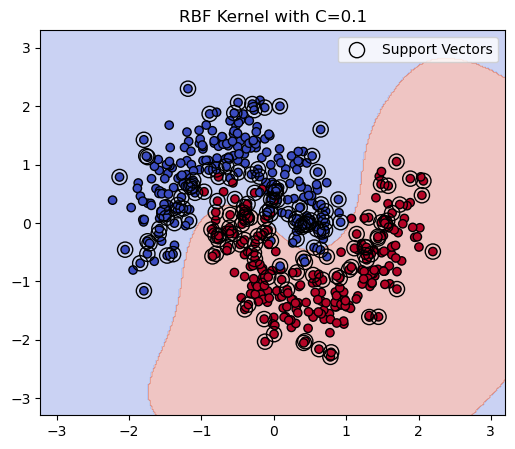

C = 1 → Accuracy = 0.980


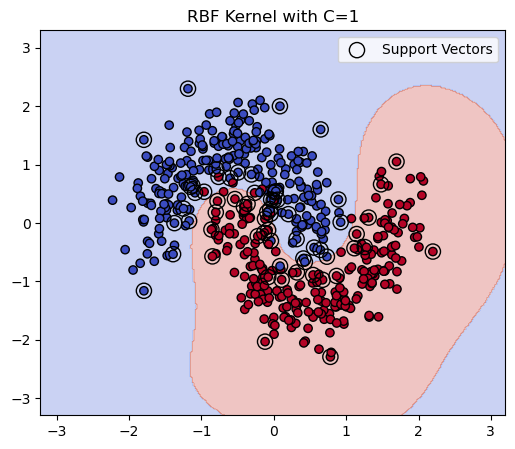

C = 10 → Accuracy = 0.973


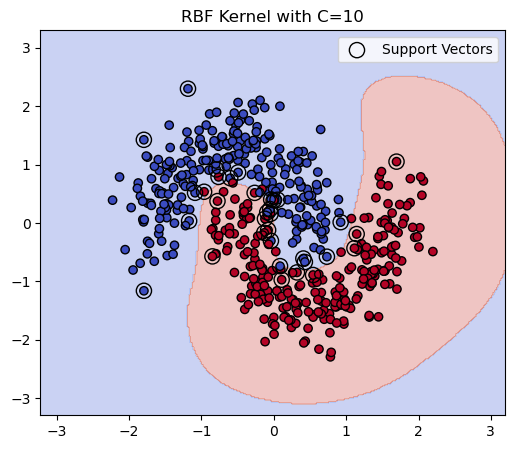

C = 100 → Accuracy = 0.967


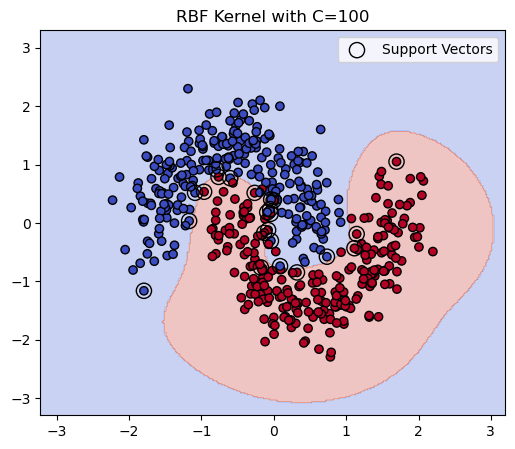

In [5]:
# ==========================================================
# PART C — EFFECT OF C PARAMETER (RBF)
# ==========================================================

print("\n================ Effect of C (RBF Kernel) ================\n")

C_values = [0.1, 1, 10, 100]

X = StandardScaler().fit_transform(X_moons)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_moons, test_size=0.3, random_state=42
)

for C in C_values:
    model = svm.SVC(kernel='rbf', C=C, gamma=1)
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    print(f"C = {C} → Accuracy = {acc:.3f}")
    plot_decision_boundary(model, X, y_moons, f"RBF Kernel with C={C}")


================ Effect of Gamma (RBF Kernel) ================

Gamma = 0.1 → Accuracy = 0.880


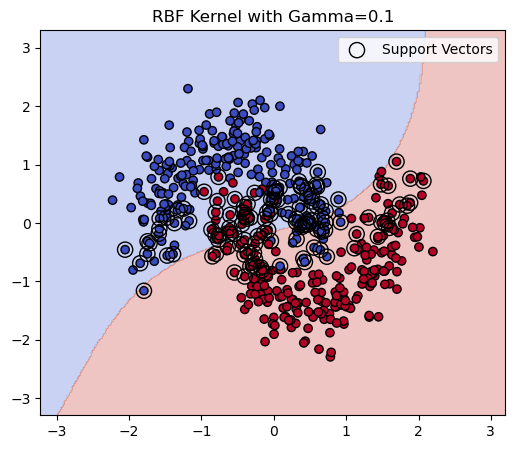

Gamma = 0.5 → Accuracy = 0.973


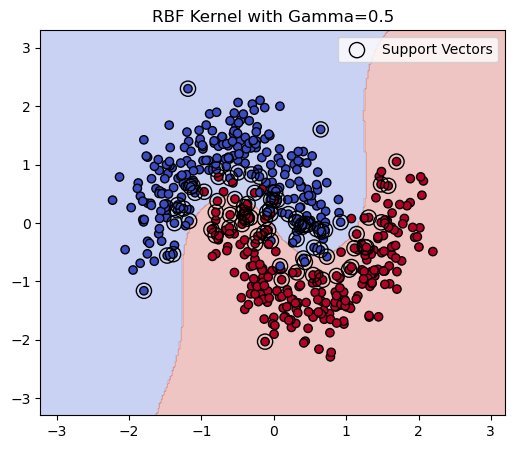

Gamma = 1 → Accuracy = 0.980


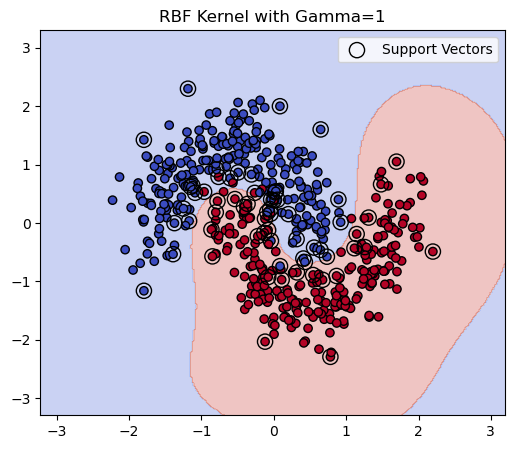

Gamma = 5 → Accuracy = 0.980


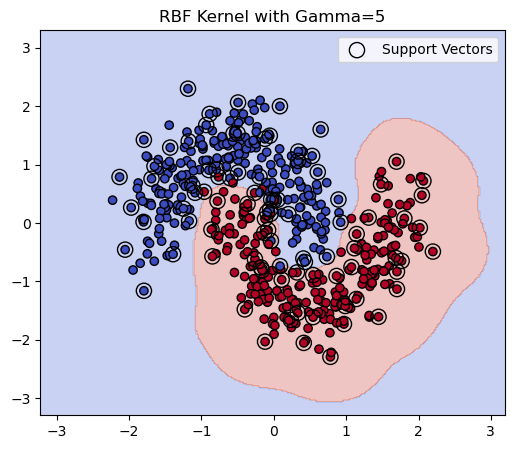

In [6]:
# ==========================================================
# PART D — EFFECT OF GAMMA
# ==========================================================

print("\n================ Effect of Gamma (RBF Kernel) ================\n")

gamma_values = [0.1, 0.5, 1, 5]

for g in gamma_values:
    model = svm.SVC(kernel='rbf', gamma=g, C=1)
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    print(f"Gamma = {g} → Accuracy = {acc:.3f}")
    plot_decision_boundary(model, X, y_moons, f"RBF Kernel with Gamma={g}")